# FlowMatchLY testing

Validation for the conditional flow-matching model of `p(light yield | event params, detector position)`.

Ordered so that failures are diagnosed bottom-up:

1. **Density normalisation** — is the ODE/divergence integration correct at all?
2. **ODE step convergence** — how many integration steps do we actually need?
3. **Marginal consistency** — averaging `p(q|c)` over the data's own contexts must return `p(q)`.
4. **Calibration (PIT)** — the real test: is the *conditional* distribution right?
5. **Per-event conditional PMF** — eyeball one event.
6. **Conditional trends** — does `E[q|c]` track the physics (distance, energy)?
7. **Sliced distributions** — do the shapes match inside bins of a conditioning variable?

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import nugget
from scipy import stats

importlib.reload(nugget.surrogates.FlowMatchLY)
from nugget.surrogates.FlowMatchLY import FlowMatchLY, LightYieldFlowDataset

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## Config and model

In [2]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

GEOM         = '../other/800_40_40_geom.csv'
TEST_PARQUET = './flow_models/mc_ly_muon_flow_v1_test_samples.parquet'
CHECKPOINT   = './flow_models/best_mc_ly_muon_flow_model_v1.pt'
HISTORY      = './flow_models/mc_ly_muon_flow_v1_training_history.pkl'

N_STEPS = 64      # ODE steps for sampling / density
N_EVAL  = 20000   # rows used for the statistical tests

flow = FlowMatchLY(device=device, domain_size=8000)
flow.load_model(CHECKPOINT)     # restores architecture + normalisers
flow.net.eval()
print('context_dim =', flow.context_dim)
print('target transform: log10(q + u), mu = %.4f, sigma = %.4f'
      % (flow.target_mu, flow.target_sigma))

FlowMatchLY: context_dim=15, width=256, depth=6, params=1,849,857
context_dim = 15
target transform: log10(q + u), mu = 0.3301, sigma = 0.3393


In [24]:
ds = LightYieldFlowDataset(
    flow,
    parquet_path=TEST_PARQUET,
    geometry_csv_path=GEOM,
    # seed=0,
    uniform_energy_zenith=False,   # test on the NATURAL row distribution
    filter_vertex_in_domain=True,
)

# One fixed evaluation batch, reused by every test below.
rng = np.random.default_rng()
rows = rng.integers(0, ds._n_rows, size=N_EVAL)
ctx = flow.build_context(
    torch.from_numpy(ds._point[rows]),
    torch.from_numpy(ds._muon_pos[rows]),
    torch.from_numpy(ds._energy[rows]),
    torch.from_numpy(ds._zenith[rows]),
    torch.from_numpy(ds._azimuth[rows]),
    torch.from_numpy(ds._pmt_direction[rows]),
).to(device)
q_true = ds._count[rows].astype(np.float64)
print(f'{N_EVAL:,} eval rows | q: P(q=1)={np.mean(q_true==1):.4f} '
      f'median={np.median(q_true):.0f} mean={q_true.mean():.2f} max={q_true.max():.0f}')

LightYieldFlowDataset: dropped 45181 row(s) with muon vertex outside [4000.0, 4000.0, 4000.0]
LightYieldFlowDataset: 1,067,279 rows, 11,053 events, 1,067,279 samples/epoch
20,000 eval rows | q: P(q=1)=0.6784 median=1 mean=7.16 max=32061


## Training history

The flow-matching loss has a **non-zero floor**: the regression target `x1 - x0` is random
given `x_t`, so the irreducible loss is its conditional variance. Only *relative* changes are
meaningful — there is no "0 is perfect" here.

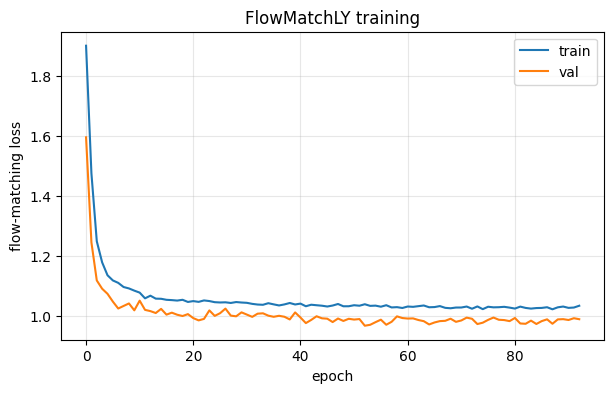

best val: 0.9663655777127812


In [25]:
hist = pickle.load(open(HISTORY, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist['train_loss'], label='train')
if hist.get('val_loss'):
    plt.plot(hist['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('flow-matching loss'); plt.legend()
plt.title('FlowMatchLY training'); plt.grid(alpha=.3); plt.show()
print('best val:', min(hist['val_loss']) if hist.get('val_loss') else 'n/a')

## Test 1 — density normalisation

`integral p(z|c) dz` must be 1. This is the single most important sanity check: a sign error in
the divergence accumulation still produces plausible-looking *samples* while silently corrupting
every likelihood. If this fails, nothing below is trustworthy.

In [26]:
zs = torch.linspace(-8, 8, 1601, device=device, dtype=torch.get_default_dtype()).reshape(-1, 1)
print('integral of p(z|c) dz   (should be 1.000)')
for k in range(5):
    cc = ctx[k:k+1].repeat(len(zs), 1)
    lp = flow.log_prob_z(zs, cc, n_steps=N_STEPS)
    integral = torch.trapezoid(lp.exp().double(), zs.reshape(-1).double()).item()
    print(f'  context {k}: {integral:.5f}')

integral of p(z|c) dz   (should be 1.000)
  context 0: 1.00501
  context 1: 1.00552
  context 2: 1.02684
  context 3: 1.02187
  context 4: 1.01161


## Test 2 — ODE step convergence

How many integration steps are actually needed? Pick the knee, not the largest value.

In [6]:
sub = ctx[:2000]
q_sub = torch.from_numpy(q_true[:2000]).to(device)
ref = flow.log_prob_light_yield(q_sub, sub, n_steps=256).double()
print('n_steps   mean|log p - log p(256 steps)|')
for n in [4, 8, 16, 32, 64, 128]:
    lp = flow.log_prob_light_yield(q_sub, sub, n_steps=n).double()
    print(f'  {n:4d}     {(lp - ref).abs().mean().item():.5f}')

n_steps   mean|log p - log p(256 steps)|
     4     0.27863
     8     0.19552
    16     0.15483
    32     0.13708
    64     0.13641
   128     0.13500


## Test 3 — marginal consistency

Averaging `p(q|c)` over the data's own `(θ, x)` must reproduce the unconditional `p(q)`.
This is a **necessary** condition, cheap to check, and catches gross failures — but it is not
sufficient, since it averages over the conditioning. Test 4 is the sharper one.

data   P(q=1)=0.6784  P(q<=2)=0.8123  P(q<=10)=0.9564  median=  1.0  mean=    7.16  q99=     54  max=32061
flow   P(q=1)=0.6642  P(q<=2)=0.8041  P(q<=10)=0.9530  median=  1.0  mean=    6.65  q99=     57  max=11428


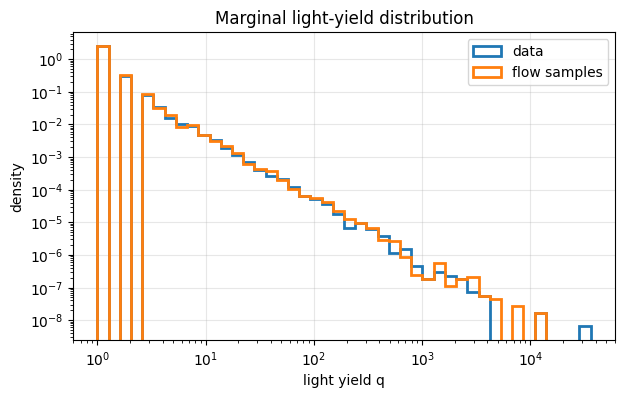

In [29]:
q_samp = flow.sample_light_yield(ctx, n_steps=N_STEPS).cpu().numpy().astype(np.float64)

def summarise(name, a):
    print(f'{name:6s} P(q=1)={np.mean(a==1):.4f}  P(q<=2)={np.mean(a<=2):.4f}  '
          f'P(q<=10)={np.mean(a<=10):.4f}  median={np.median(a):5.1f}  '
          f'mean={a.mean():8.2f}  q99={np.quantile(a,.99):7.0f}  max={a.max():.0f}')
summarise('data', q_true); summarise('flow', q_samp)

bins = np.logspace(0, np.log10(max(q_true.max(), q_samp.max())) + .05, 45)
plt.figure(figsize=(7, 4))
plt.hist(q_true, bins=bins, histtype='step', lw=2, density=True, label='data')
plt.hist(q_samp, bins=bins, histtype='step', lw=2, density=True, label='flow samples')
plt.xscale('log'); plt.yscale('log'); plt.xlabel('light yield q'); plt.ylabel('density')
plt.legend(); plt.title('Marginal light-yield distribution'); plt.grid(alpha=.3); plt.show()

## Test 4 — calibration (PIT)

The real test of the *conditional* distribution.

Because we dequantise (`q̃ = q + u`, `u ~ U(0,1)`), the target is genuinely continuous, so the
ordinary PIT applies: if the model is correct then `F(q̃ | c) ~ Uniform(0,1)`.

`cdf_light_yield` is exact rather than a numerical integral — in 1-D the flow map is monotone,
so the CDF is just the base-space Gaussian CDF of the backward-transported point.

Read the shape of a miscalibrated histogram:
- **U-shaped** → too narrow (over-confident)
- **∩-shaped** → too wide (under-confident)
- **sloped** → biased

PIT mean = 0.4944 (want 0.5),  std = 0.2859 (want 0.2887)
KS vs Uniform(0,1): stat = 0.0120, p = 0.00619


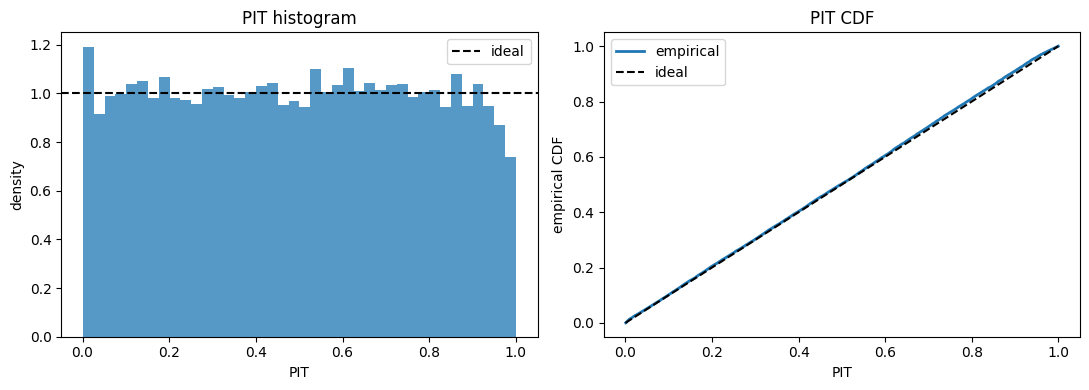

In [8]:
u = torch.rand(len(q_true), device=device, dtype=ctx.dtype)
q_deq = torch.from_numpy(q_true).to(device).to(ctx.dtype) + u
pit = flow.cdf_light_yield(q_deq, ctx, n_steps=N_STEPS).cpu().numpy()

ks = stats.kstest(pit, 'uniform')
print(f'PIT mean = {pit.mean():.4f} (want 0.5),  std = {pit.std():.4f} (want {1/np.sqrt(12):.4f})')
print(f'KS vs Uniform(0,1): stat = {ks.statistic:.4f}, p = {ks.pvalue:.3g}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(pit, bins=40, density=True, color='tab:blue', alpha=.75)
ax[0].axhline(1.0, color='k', ls='--', label='ideal')
ax[0].set_xlabel('PIT'); ax[0].set_ylabel('density'); ax[0].set_title('PIT histogram'); ax[0].legend()
ax[1].plot(np.sort(pit), np.linspace(0, 1, len(pit)), lw=2, label='empirical')
ax[1].plot([0, 1], [0, 1], 'k--', label='ideal')
ax[1].set_xlabel('PIT'); ax[1].set_ylabel('empirical CDF'); ax[1].set_title('PIT CDF'); ax[1].legend()
plt.tight_layout(); plt.show()

### Calibration split by light yield

A model can be calibrated on average while being wrong in the tail — which is exactly where
`E[q]` lives. Check the PIT separately per decade of `q`.

In [9]:
print(f'{"q range":>14}  {"n":>7}  {"PIT mean":>9}  {"KS stat":>8}  {"p":>9}')
for lo, hi in [(1, 2), (2, 10), (10, 100), (100, 1000), (1000, 1e9)]:
    m = (q_true >= lo) & (q_true < hi)
    if m.sum() < 50:
        continue
    k = stats.kstest(pit[m], 'uniform')
    print(f'[{lo:>6.0f},{hi:>7.0f})  {m.sum():>7d}  {pit[m].mean():>9.4f}  '
          f'{k.statistic:>8.4f}  {k.pvalue:>9.2e}')

       q range        n   PIT mean   KS stat          p
[     1,      2)    13748     0.3755    0.1936   0.00e+00
[     2,     10)     5291     0.7407    0.3876   0.00e+00
[    10,    100)      872     0.8356    0.5174  1.89e-217
[   100,   1000)       81     0.8640    0.5819   1.42e-26


## Test 5 — one event's conditional distribution

`q` is discrete, so the honest object is a **PMF**, not a density. We evaluate
`P(q=k|c) = integral over [k, k+1) of p(q̃|c)` using the exact CDF at the bin edges.

row 906911: q_true = 152, E_nu = 6.97e+05 GeV, zenith = 1.238 rad


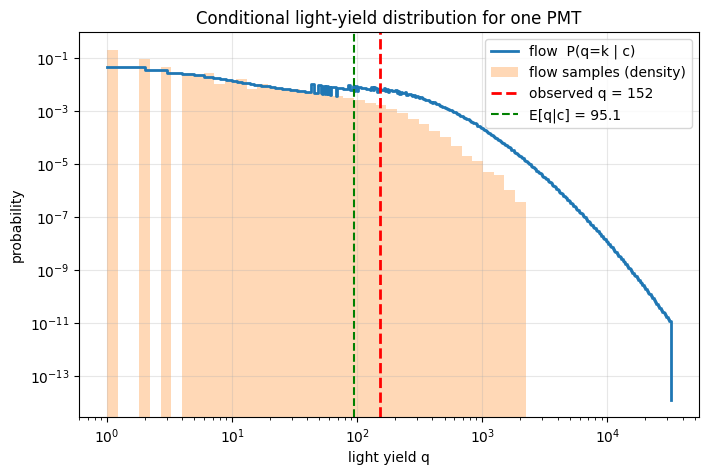

sum of PMF over grid = 1.0000  (<1 means the grid truncates the tail)


In [51]:
# row_i = int(np.argmax(q_true > 1)) if np.any(q_true > 1) else 0
thres_q = 100
test_q = 0
while test_q < thres_q:
      row_i = np.random.randint(0, len(q_true))  # random row for conditional distribution plot
      test_q = q_true[row_i]
c1 = ctx[row_i:row_i+1]
print(f'row {rows[row_i]}: q_true = {q_true[row_i]:.0f}, '
      f'E_nu = {ds._energy[rows[row_i]]:.3g} GeV, zenith = {ds._zenith[rows[row_i]]:.3f} rad')

k_grid = np.unique(np.round(np.logspace(0, np.log10(max(q_true.max(), 1e3)), 400)).astype(int))
edges = torch.tensor(np.concatenate([k_grid, [k_grid[-1] + 1]]), device=device,
                     dtype=ctx.dtype)
cdf_edges = flow.cdf_light_yield(edges, c1.repeat(len(edges), 1), n_steps=N_STEPS).cpu().numpy()
pmf = np.diff(cdf_edges)
pmf = np.clip(pmf, 0, None)

samp = flow.sample_light_yield(c1.repeat(20000, 1), n_steps=N_STEPS).cpu().numpy()
exp_q = float((k_grid * pmf).sum() / max(pmf.sum(), 1e-12))

plt.figure(figsize=(8, 5))
plt.step(k_grid, pmf, where='post', lw=2, label='flow  P(q=k | c)')
plt.hist(samp, bins=np.logspace(0, np.log10(samp.max() + 1), 40), density=True,
         alpha=.3, label='flow samples (density)')
plt.axvline(q_true[row_i], color='red', ls='--', lw=2, label=f'observed q = {q_true[row_i]:.0f}')
plt.axvline(exp_q, color='green', ls='--', label=f'E[q|c] = {exp_q:.1f}')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('light yield q'); plt.ylabel('probability')
plt.legend(); plt.title('Conditional light-yield distribution for one PMT'); plt.grid(alpha=.3)
plt.show()

print(f'sum of PMF over grid = {pmf.sum():.4f}  (<1 means the grid truncates the tail)')

## Test 6 — conditional trends

Does `E[q|c]` follow the physics? Compare the model's conditional mean against the binned
empirical mean, as a function of perpendicular distance to the track and of energy.

Note `E[q]` is the **least reliable** thing to ask for: the distribution is tail-dominated, so
this plot has large error bars in the data itself. `exp(E[log q])` is far more stable.

In [ ]:
pts, vert = ds._point[rows], ds._muon_pos[rows]
zen, azi = ds._zenith[rows], ds._azimuth[rows]
u_dir = np.stack([np.sin(zen)*np.cos(azi), np.sin(zen)*np.sin(azi), np.cos(zen)], 1)
rel = pts - vert
along = (rel * u_dir).sum(1)
perp = np.linalg.norm(rel - along[:, None] * u_dir, axis=1)
logE = np.log10(ds._energy[rows])

n_s = 128
rep = ctx.repeat_interleave(n_s, 0)
q_mc = flow.sample_light_yield(rep, n_steps=N_STEPS).reshape(len(q_true), n_s).cpu().numpy()
model_geo = np.exp(np.log(np.clip(q_mc, 1, None)).mean(1))   # exp E[log q]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, x, lab in [(ax[0], perp, 'perpendicular distance to track [m]'),
                  (ax[1], logE, 'log10(neutrino energy / GeV)')]:
    qs = np.quantile(x, np.linspace(0, 1, 13))
    idx = np.digitize(x, qs[1:-1])
    cx = [x[idx == b].mean() for b in range(12) if (idx == b).sum() > 20]
    dy = [np.exp(np.log(np.clip(q_true[idx == b], 1, None)).mean())
          for b in range(12) if (idx == b).sum() > 20]
    my = [np.exp(np.log(np.clip(model_geo[idx == b], 1, None)).mean())
          for b in range(12) if (idx == b).sum() > 20]
    a.plot(cx, dy, 'o-', label='data')
    a.plot(cx, my, 's--', label='flow')
    a.set_xlabel(lab); a.set_ylabel('exp E[log q]'); a.set_yscale('log')
    a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 9.77 GiB. GPU 1 has a total capacity of 39.52 GiB of which 1.34 GiB is free. Process 3072895 has 494.00 MiB memory in use. Including non-PyTorch memory, this process has 37.68 GiB memory in use. Of the allocated memory 32.75 GiB is allocated by PyTorch, and 4.43 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

: 

## Test 7 — sliced distributions

Test 3 could pass while every conditional is wrong in compensating ways. Slice by a
conditioning variable and compare the *shapes* inside each slice.

In [ ]:
qs = np.quantile(perp, [0, .25, .5, .75, 1.0])
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6), sharey=True)
for i in range(4):
    m = (perp >= qs[i]) & (perp < qs[i+1] if i < 3 else perp <= qs[i+1])
    if m.sum() < 100:
        continue
    b = np.logspace(0, np.log10(max(q_true[m].max(), q_samp[m].max())) + .05, 30)
    ax[i].hist(q_true[m], bins=b, histtype='step', lw=2, density=True, label='data')
    ax[i].hist(q_samp[m], bins=b, histtype='step', lw=2, density=True, label='flow')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].set_title(f'perp in [{qs[i]:.0f}, {qs[i+1]:.0f}) m\nn={m.sum()}')
    ax[i].set_xlabel('q'); ax[i].grid(alpha=.3)
    ks = stats.ks_2samp(q_true[m], q_samp[m])
    ax[i].text(.05, .05, f'KS={ks.statistic:.3f}', transform=ax[i].transAxes)
ax[0].set_ylabel('density'); ax[0].legend()
plt.tight_layout(); plt.show()

## Summary checklist

| test | pass condition |
|---|---|
| 1 normalisation | integrals within ~1% of 1.0 |
| 2 ODE steps | log-prob flat beyond the chosen `N_STEPS` |
| 3 marginal | `P(q=1)`, quantiles, and the histogram overlay agree |
| 4 PIT | flat histogram, diagonal CDF, no strong slope or U-shape |
| 4b PIT by decade | no decade badly skewed (watch the tail) |
| 5 single event | PMF sums to ~1 over the grid; observed `q` in a plausible region |
| 6 trends | flow tracks the data curve vs distance and energy |
| 7 slices | shapes agree inside each slice, small KS |

A **U-shaped PIT** with a good marginal is the classic signature of a model that has learned
`p(q)` but not the conditioning — check that the context is actually reaching the network.